# **CARGAR LIBRERIAS**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

**CARGAR DATOS**

In [6]:
# Cargamos los datos
df = pd.read_excel("datos.xlsx")
df.head(2)

,Muestra,Productos-Lote,Tiempo-Entrega,Defectuoso
0,1,19,19000,0
1,2,35,20000,0


In [7]:
X1 = 'Productos-Lote'
X2 = 'Tiempo-Entrega'
Y = 'Defectuoso'

C:\Users\wilbe\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


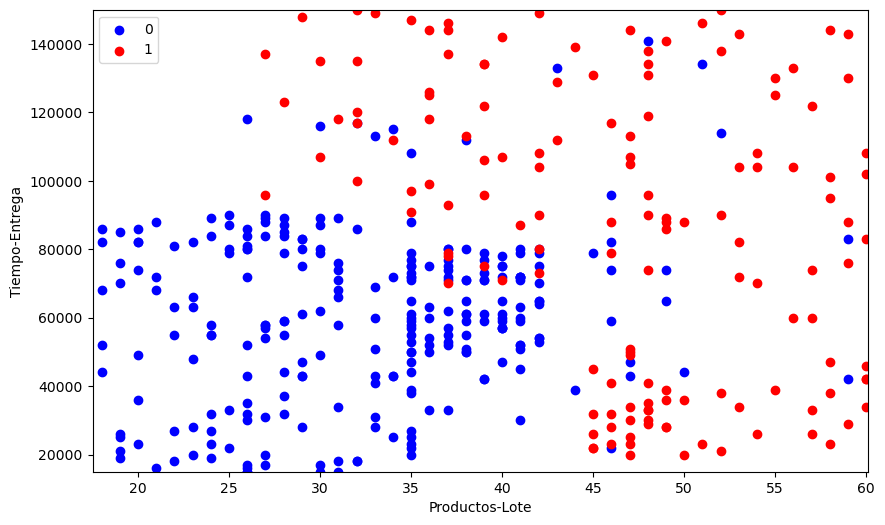

In [8]:
import matplotlib.pyplot as plt
import numpy as np
X = df[[X1, X2]] 
y = df[Y]
# Entrena el modelo con todos los datos
model = LogisticRegression(solver='liblinear')
model.fit(X, y)
# Crea una malla para evaluar el modelo
x_min, x_max = X[X1].min() - 0.5, X[X1].max() + 0.5
y_min, y_max = X[X2].min() - 0.5, X[X2].max() + 0.5
h = (x_max - x_min)/100
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# Predice en todos los puntos de la malla
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Crea el gráfico de dispersión de los datos
plt.figure(figsize=(10, 6))
plt.scatter(X[y == 0][X1], X[y == 0][X2], color='blue', label='0')
plt.scatter(X[y == 1][X1], X[y == 1][X2], color='red', label='1')
# Dibuja la frontera de decisión
plt.contour(xx, yy, Z, cmap=plt.cm.Paired)
# Etiquetas y leyenda
plt.xlabel(X1)
plt.ylabel(X2)
plt.legend()
plt.show()

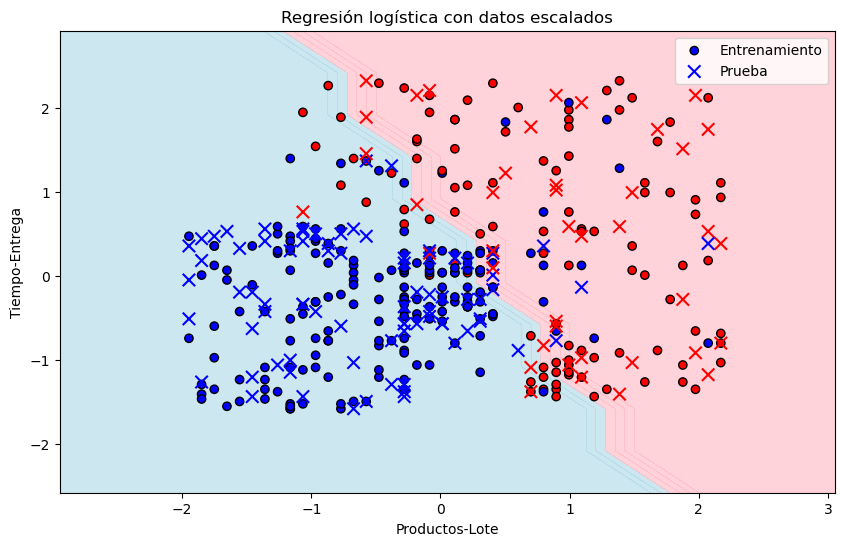

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap

# Variables
X1 = 'Productos-Lote'
X2 = 'Tiempo-Entrega'
Y  = 'Defectuoso'


# Train / Test (30% test)

X = df[[X1, X2]]
y = df[Y]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# Escalado (SOLO con train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modelo

model = LogisticRegression(solver='liblinear')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# ===== Frontera de decisión =====
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

h = 0.5   # resolución segura (clave para no explotar RAM)

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Colores
cmap_light = ListedColormap(["#ADD8E6", "#FFB6C1"])
cmap_bold = ["blue", "red"]

# ===== Gráfico =====
plt.figure(figsize=(10, 6))

# Frontera
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

# Entrenamiento
plt.scatter(
    X_train_scaled[:, 0], X_train_scaled[:, 1],
    c=y_train, cmap=ListedColormap(cmap_bold),
    edgecolor='k', label='Entrenamiento'
)

# Prueba
plt.scatter(
    X_test_scaled[:, 0], X_test_scaled[:, 1],
    c=y_test, cmap=ListedColormap(cmap_bold),
    marker='x', s=80, label='Prueba'
)

plt.xlabel(X1)
plt.ylabel(X2)
plt.title("Regresión logística con datos escalados")
plt.legend()
plt.show()


In [41]:
print(X_test_scaled.shape)  # (n, 2)
print(y_test.shape)         # (n,)

(120, 2)
(120,)


In [42]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))


[[74  5]
 [10 31]]


In [43]:
score = model.score(X_test_scaled, y_test)
score


0.875

In [44]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)


0.875

# **USO DEL MODELO PARA PREDICIR**

In [11]:
# Definir las características de las dos variables predictoras
Variable_x1 = 59.7
Variable_x2 = 69742.500000

new_example = pd.DataFrame([[Variable_x1, Variable_x2]], columns=['Productos-Lote', 'Tiempo-Entrega'])
# Escalar las características para que coincidan con la escala de los datos de entrenamiento
new_example_scaled = scaler.transform(new_example)
# Usar el modelo para hacer una predicción
prediction = model.predict(new_example_scaled)
# Define una frase de resultado personalizada basada en la predicción
result_phrase = "DEFECTUOSO" if prediction[0] == 1 else "NO DEFECTUOSO"
print("Un producto que este dentro de un lote de", Variable_x1, "unidades y dure",Variable_x2 ,"minutos en su entrega, es problable que estará en estado:", result_phrase)

Un producto que este dentro de un lote de 59.7 unidades y dure 69742.5 minutos en su entrega, es problable que estará en estado: DEFECTUOSO


# Con datos de pruebas y escalado

In [45]:
df = pd.read_excel("datos.xlsx")
df.head()

,Muestra,Productos-Lote,Tiempo-Entrega,Defectuoso
0,1,19,19000,0
1,2,35,20000,0
2,3,26,43000,0
3,4,27,57000,0
4,5,19,76000,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Muestra         400 non-null    int64
 1   Productos-Lote  400 non-null    int64
 2   Tiempo-Entrega  400 non-null    int64
 3   Defectuoso      400 non-null    int64
dtypes: int64(4)
memory usage: 12.6 KB


In [47]:
df.describe()

,Muestra,Productos-Lote,Tiempo-Entrega,Defectuoso
count,400.000000,400.000000,400.000000,400.000000
mean,200.500000,37.655000,69742.500000,0.357500
std,115.614301,10.482877,34096.960282,0.479864
min,1.000000,18.000000,15000.000000,0.000000
25%,100.750000,29.750000,43000.000000,0.000000
50%,200.500000,37.000000,70000.000000,0.000000
75%,300.250000,46.000000,88000.000000,1.000000
max,400.000000,60.000000,150000.000000,1.000000


In [48]:
X = df.iloc[:,[1,3]].values

In [49]:
y.head(2)

0    0
1    0
Name: Defectuoso, dtype: int64

In [50]:
# dividimos el cojunto de datos
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [51]:
# estandarizacion de escalas
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [52]:
X_train.shape

(300, 2)

In [53]:
# Clasifiacador con regrecion logistica
from sklearn.linear_model import LogisticRegression
clasificador = LogisticRegression(random_state=0)
clasificador.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [54]:
# prediccion del cojunto
y_pred = clasificador.predict(X_test)

In [55]:
# Matrz de confucion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[68,  0],
       [ 0, 32]])

In [56]:
score = clasificador.score(X_test,y_test)
score

1.0

In [57]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\wilbe\AppData\Local\Temp\ipykernel_8208\1652618378.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


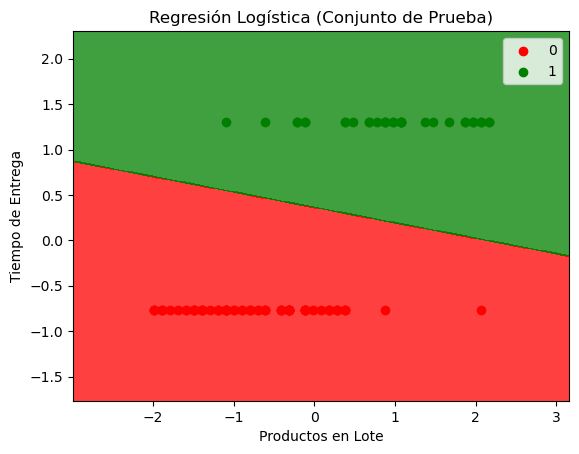

In [58]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    clasificador.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Regresión Logística (Conjunto de Prueba)')
plt.xlabel('Productos en Lote')
plt.ylabel('Tiempo de Entrega')
plt.legend()
plt.show()


In [59]:
# Definir las características de las dos variables predictoras
Variable_x1 = 59.7
Variable_x2 = 69742.500000

new_example = pd.DataFrame(
    [[Variable_x1, Variable_x2]],
    columns=['Productos-Lote', 'Tiempo-Entrega']
)

new_example_scaled = scaler.transform(new_example)
prediction = clasificador.predict(new_example_scaled)

# Define una frase de resultado personalizada basada en la predicción
result_phrase = "DEFECTUOSO" if prediction[0] == 1 else "NO DEFECTUOSO"
print("Un producto que este dentro de un lote de", Variable_x1, "unidades y dure",Variable_x2 ,"minutos en su entrega, es problable que estará en estado:", result_phrase)

Un producto que este dentro de un lote de 59.7 unidades y dure 69742.5 minutos en su entrega, es problable que estará en estado: NO DEFECTUOSO


# Conclucion

En la regresión logística escalada los datos presentan una separación lineal clara entre las clases de 100%, lo que permite una mejor capacidad de generalización frente a la otra, el cual tiene un 87.5%  . Además, el escalado se realizó correctamente evitando fuga de información.